In [1]:
%load_ext autoreload
%autoreload 2

In [43]:
import matplotlib.pyplot as plt
from skimage import io, color, transform
from src.normalizedCut import *
import os

In [57]:
data_dir = 'data/data_Ncut/'
image_names = os.listdir(data_dir)
resize_shape = (60, 60)

## Q1. Graph Based Image Segmentation using Normalized Cuts

#### 1.a) Compare Ncut with original weights vs improvised weights

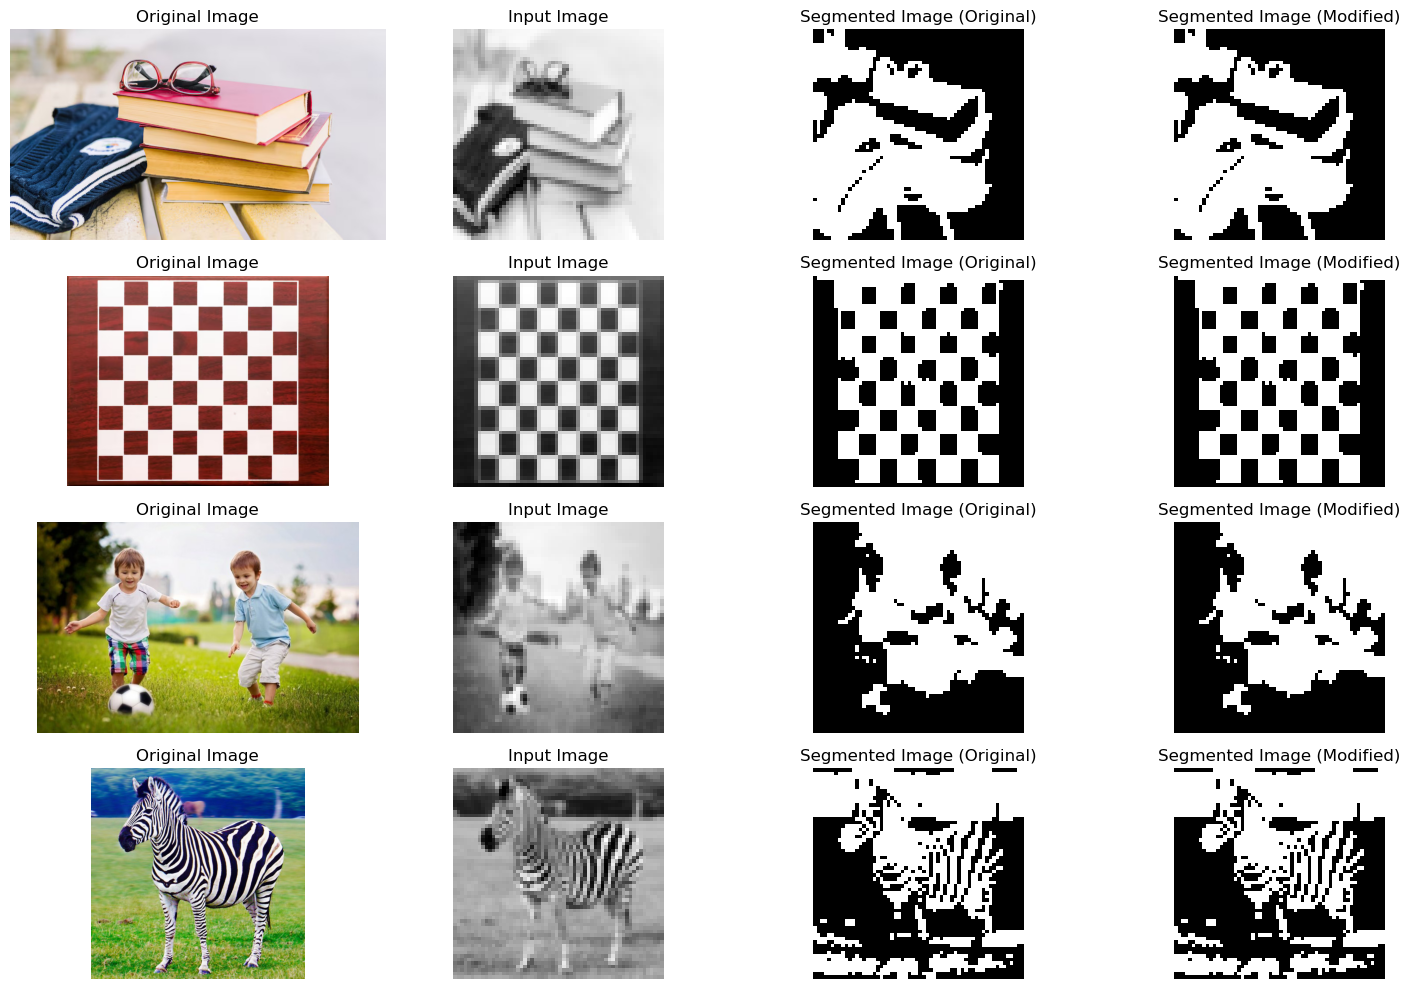

In [58]:
fig,axes = plt.subplots(nrows=len(image_names), ncols=4, figsize = (15, 10))

for idx, img_name in enumerate(image_names):
    img = io.imread(data_dir + img_name)
    Ncut_model = NormalizedCut()
    Ncut_model.fit(img, resize = resize_shape)

    Ncut_model.build_W(use_edge=False)
    Ncut_model.solve_nCut()
    segment_original = Ncut_model.partition_twoWay()

    Ncut_model.build_W(use_edge=True)
    Ncut_model.solve_nCut()
    segment_modified = Ncut_model.partition_twoWay()

    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title("Original Image")
    axes[idx, 0].axis('off')
    axes[idx, 1].imshow(color.rgb2gray(transform.resize(img, resize_shape, anti_aliasing=True)), cmap='gray')
    axes[idx, 1].set_title("Input Image")
    axes[idx, 1].axis('off')
    axes[idx, 2].imshow(segment_original, cmap='gray')
    axes[idx, 2].set_title("Segmented Image (Original)")
    axes[idx, 2].axis('off')
    axes[idx, 3].imshow(segment_modified, cmap='gray')
    axes[idx, 3].set_title("Segmented Image (Modified)")
    axes[idx, 3].axis('off')
plt.tight_layout()
plt.show()

#### 1.b) Compare Ncut with different STD values

In [59]:
SigmaIList = [0.01, 0.1, 1]
SigmaXList = [2, 10, 50]

In [60]:
image = io.imread(data_dir + 'books.jpg')

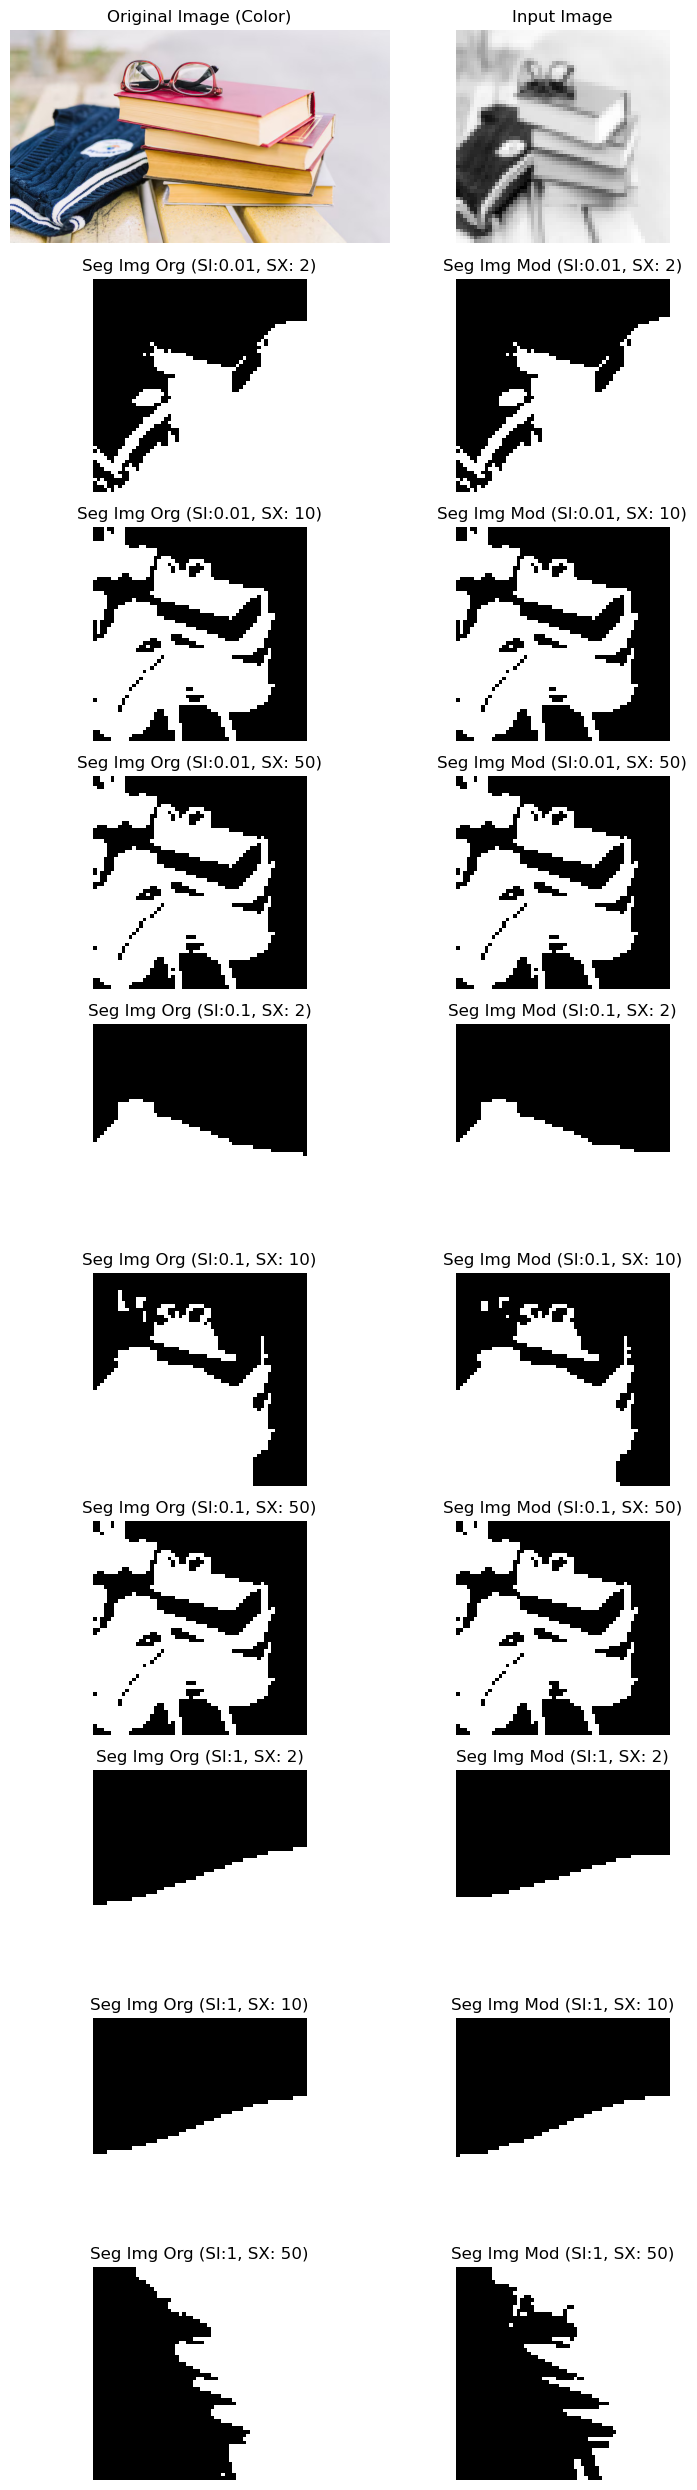

In [61]:
fig = plt.figure(figsize=(8, 25))

nrows = (len(SigmaIList) * len(SigmaXList) + 1)
ax = fig.add_subplot(nrows, 2, 1)
ax.imshow(image)
ax.set_title("Original Image (Color)")
ax.axis('off')
ax = fig.add_subplot(nrows, 2, 2)
ax.imshow(color.rgb2gray(transform.resize(image, resize_shape, anti_aliasing=True)), cmap = 'gray')
ax.set_title("Input Image")
ax.axis('off')

count = 3
for sI in SigmaIList:
    for sX in SigmaXList:
            Ncut_model = NormalizedCut(sigmaI = sI, sigmaX = sX)
            Ncut_model.fit(image, resize=resize_shape)

            Ncut_model.build_W(use_edge=False)
            Ncut_model.solve_nCut()
            segment_original = Ncut_model.partition_twoWay()
            ax = fig.add_subplot(nrows, 2, count)
            ax.imshow(segment_original, cmap='gray')
            ax.set_title(f"Seg Img Org (SI:{sI}, SX: {sX})")
            ax.axis('off')

            Ncut_model.build_W(use_edge=True)
            Ncut_model.solve_nCut()
            segment_modified = Ncut_model.partition_twoWay()
            ax = fig.add_subplot(nrows, 2, count + 1)
            ax.imshow(segment_modified, cmap='gray')
            ax.set_title(f"Seg Img Mod (SI:{sI}, SX: {sX})")
            ax.axis('off')

            count+=2
plt.tight_layout()
plt.show()

#### 1.c) Compare Recursive Two Way vs Simultaneous Partitioning Using KMeans

In [64]:
K = 4

In [62]:
def labels_to_grayscale(labels, K):
    scaled_img = (labels.astype(float) / (K - 1)) * 255.0
    return np.round(scaled_img).astype(np.uint8)

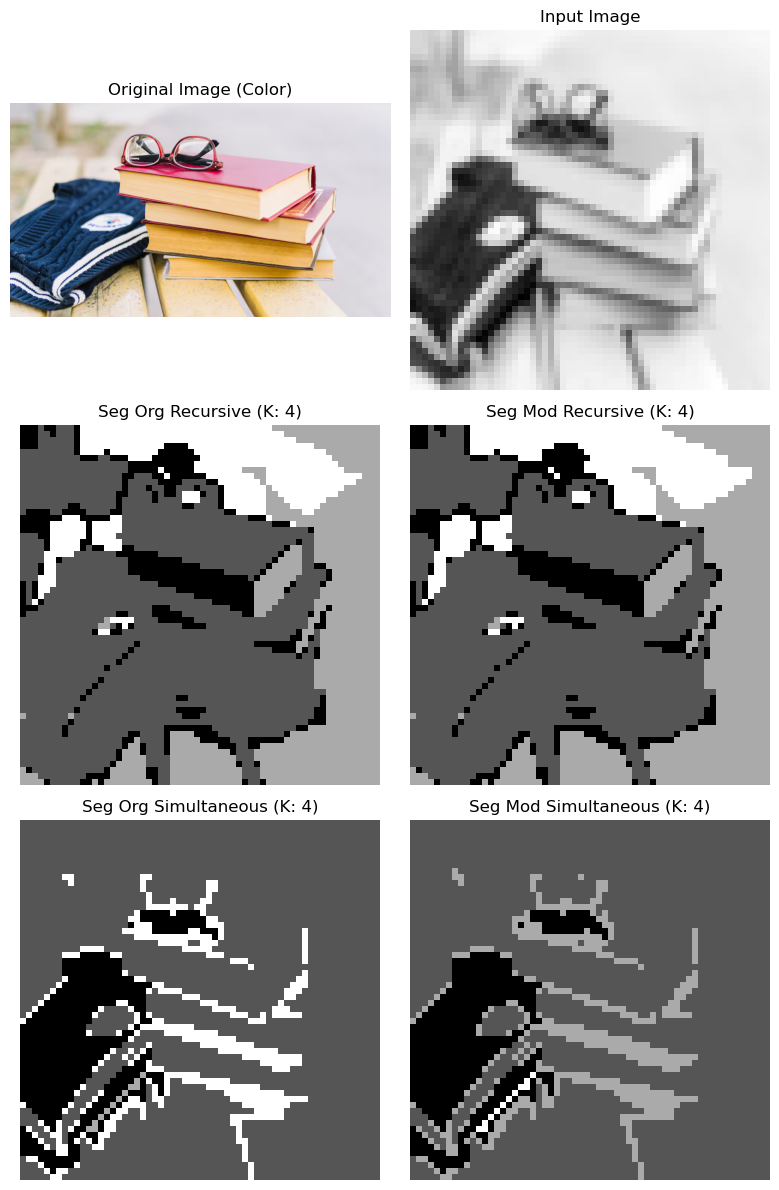

In [75]:
fig = plt.figure(figsize=(8, 12))

nrows = 3
ax = fig.add_subplot(nrows, 2, 1)
ax.imshow(image)
ax.set_title("Original Image (Color)")
ax.axis('off')
ax = fig.add_subplot(nrows, 2, 2)
ax.imshow(color.rgb2gray(transform.resize(image, resize_shape, anti_aliasing=True)), cmap = 'gray')
ax.set_title("Input Image")
ax.axis('off')

for i in range(3, 7, 2):

    Ncut_model = NormalizedCut()
    Ncut_model.fit(image, resize=resize_shape)

    Ncut_model.build_W(use_edge=False)
    Ncut_model.solve_nCut()
    ax = fig.add_subplot(nrows, 2, i)
    if i == 3:
        segment_original = Ncut_model.partition_recursive_Kway(K)
        ax.set_title(f"Seg Org Recursive (K: {K})")
    else: 
        segment_original = Ncut_model.partition_Ksimultaneous(K)
        ax.set_title(f"Seg Org Simultaneous (K: {K})")
    segment_original = labels_to_grayscale(segment_original, K)
    ax.imshow(segment_original, cmap='gray')
    ax.axis('off')

    Ncut_model.build_W(use_edge=True)
    Ncut_model.solve_nCut()
    ax = fig.add_subplot(nrows, 2, i + 1)
    if i == 3:
        segment_original = Ncut_model.partition_recursive_Kway(K)
        ax.set_title(f"Seg Mod Recursive (K: {K})")
    else: 
        segment_original = Ncut_model.partition_Ksimultaneous(K)
        ax.set_title(f"Seg Mod Simultaneous (K: {K})")
    segment_original = labels_to_grayscale(segment_original, K)
    ax.imshow(segment_original, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()